## 1. Preparación de datos

In [1]:
import pandas as pd

# 1. Configuración de visualización
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', 100)

data = pd.read_csv('../data/telecom_churn_clean.csv')

data.info()
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   Churn                                  7043 non-null   int64  
 4   Partner_Yes                            7043 non-null   int64  
 5   Dependents_Yes                         7043 non-null   int64  
 6   MultipleLines_Yes                      7043 non-null   int64  
 7   InternetService_Fiber optic            7043 non-null   int64  
 8   InternetService_No                     7043 non-null   int64  
 9   OnlineSecurity_Yes                     7043 non-null   int64  
 10  OnlineBackup_Yes                       7043 non-null   int64  
 11  DeviceProtectio

,SeniorCitizen,tenure,MonthlyCharges,Churn,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1
2,0,2,53.85,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,0,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0
4,0,2,70.70,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0


Vamos a proceder a separar nuestro conjunto de datos en 2 dataframes, uno con la variable objetivo únicamente (y) y otro con todas las variables predictoras (X). Dividimos a conitnuación, cada uno de estos 2 conjuntos en 2 conjuntos a su vez: Uno de entrenamiento y otro para validación o test.

In [2]:
# Separar variables predictoras y objetivo
X = data.drop(columns='Churn')
y = data['Churn']

In [3]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Una vez concluida la preparación de los datos, nos adentramos de lleno en la fase de modelado predictivo utilizando un algoritmo de Regresión Logística. Este modelo es el idóneo para nuestro problema de clasificación binaria, ya que nos permite estimar la probabilidad de que ocurra el suceso de abandono basándonos en una función sigmoide acotada estrictamente entre 0 y 1. 

In [4]:
!pip install --upgrade statsmodels

In [5]:
import statsmodels.api as sm

# Añadir una constante para el término independiente 
X_train_const = sm.add_constant(X_train)

# Crear y ajustar el modelo
logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(maxiter=100)

# Resumen completo
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.413603
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5613
Method:                           MLE   Df Model:                           20
Date:                Thu, 11 Jun 2026   Pseudo R-squ.:                  0.2851
Time:                        18:12:15   Log-Likelihood:                -2330.2
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.3246      

**Conclusiones**:

Notas Generales:

- Pseudo R-squ. (0.2851): valores entre 0.2 y 0.4 indican un buen ajuste del modelo. Se puede decir que es capaz de explicar un 28.5% más sobre la variable objetivo que el modelo nulo.
- LLR p-value (0.000): al ser menor al 5% es un buen modelo.

Examne de las Variables:
1. El peligro de la Fibra Óptica (InternetService_Fiber optic = +1.5648): Es el coeficiente positivo más alto. Tener fibra óptica multiplica drásticamente la probabilidad de que el cliente abandone la empresa. ¡Aquí hay un problema grave de negocio (quizás el servicio es caro o falla mucho)!

2. El poder de los contratos (Contract_Two year = -1.3616): Es un coeficiente negativo fortísimo. Los clientes con contratos de dos años tienen una probabilidad bajísima de irse; el contrato los retiene con éxito.

3. La fidelidad del tiempo (tenure = -0.0328): Por cada mes extra que un cliente pasa en la compañía (tenure), el riesgo de que se vaya disminuye de forma constante.

4. El método de pago conflictivo (PaymentMethod_Electronic check = +0.3835): Los clientes que pagan con cheque electrónico tienen una tendencia significativamente mayor a abandonar la empresa en comparación con los otros métodos.

Vamos a pasar a calcular los odds de los coeficientes para interpretarlos.

In [6]:
import numpy as np

# Obtener los coeficientes
coefficients = result.params

# Calcular los odds ratios aplicando exp a los coeficientes
odds_ratios = np.exp(coefficients)

# Crear un DataFrame con las dos columnas: coeficientes y odds ratios
tab_coefs_odds = pd.DataFrame({
    'Coeficientes': coefficients,
    'Odds Ratios': odds_ratios
})

# Mostrar la tabla
tab_coefs_odds.sort_values(by='Coeficientes',ascending=False)

,Coeficientes,Odds Ratios
InternetService_Fiber optic,1.564842,4.781922
StreamingTV_Yes,0.534058,1.705840
StreamingMovies_Yes,0.533336,1.704610
MultipleLines_Yes,0.458435,1.581596
PaymentMethod_Electronic check,0.383474,1.467373
PaperlessBilling_Yes,0.366793,1.443099
const,0.324560,1.383421
SeniorCitizen,0.142137,1.152735
DeviceProtection_Yes,0.126132,1.134431
PaymentMethod_Mailed check,0.111618,1.118086


Al analizar los odds, podemos interpretar por ejemplo que variables como **InternetService_Fiber optic** hacen que cuando el registro es de esta categoría, los odds respecto de cuando no tiene esta condición, aumentan en un factor 4.78. Esto hace que la **probabilidad de que el cliente abandone la compañía (Churn) sea mayor**. Es decir, que el hecho de que el usuario tenga contratada fibra óptica esté más relacionado con el hecho de que el cliente se dé de baja más que de que permanezca en la empresa.

en el otro extremo de la tabla tenemos **Contract_Two year**cuyos odds decaen al 26% de su valor, indicando que a mayor duración del contrato, más probable es que el cliente permanezca en la compañía.

Vamos ahora a analizar los valores predichos en el conjunto de entrenamiento para ver qué tal clasifica nuestro modelo según otras métricas.

In [7]:
from sklearn.metrics import confusion_matrix

# Hacer predicciones (probabilidad de clase 1)
y_proba = result.predict(X_train_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_train, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[3720  419]
 [ 683  812]]
Matriz de confusión en porcentajes:
[[66.03  7.44]
 [12.12 14.41]]


 En los resultados se muestra tanto en valor absoluto el número de registros como en porcentajes. Si vemos los porcentajes, vemos que el volumen de **falsos negativos es de un 12.12%**, tenemos un volumen muy elevado de este tipo de errores. Del mismo modo, los **falsos positivos suponen un 7.44%** que tampoco es desdeñable. En conclusión, no parece que nuestro modelo esté captando bien la variabilidad de la variable objetivo. Parece que tiene un problema de sesgo importante.  Seguimos analizando métricas del conjunto entrenado. Vamos a calcular los ratios a partir de la matriz de confusión.

In [8]:
from sklearn.metrics import classification_report

# Imprimir el reporte de clasificación con las métricas detalladas
print("Reporte de clasificación:")
print(classification_report(y_train, y_pred))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      4139
           1       0.66      0.54      0.60      1495

    accuracy                           0.80      5634
   macro avg       0.75      0.72      0.73      5634
weighted avg       0.80      0.80      0.80      5634



La exactitud global (accuracy) se sitúa en un 80%, lo que indica que el modelo acierta en 8 de cada 10 clasificaciones. A pesar de ser un porcentaje aparentemente elevado, esta métrica se encuentra inflada por la clase mayoritaria (0 - Clientes que se quedan), la cual presenta una precisión del 84% y una sensibilidad del 90%.

El verdadero desafío del negocio se encuentra en la clase positiva (1 - Churn):
- Precisión (66%): Significa que de cada 100 alertas de fuga que genera el modelo, 66 son correctas, teniendo un 34% de falsas alarmas (falsos positivos).
- Sensibilidad o Recall (54%): Este es el punto más crítico. El modelo solo es capaz de identificar y "capturar" al 54% de los clientes que realmente se van a dar de baja. Esto implica que un 46% de los clientes en riesgo de fuga se le escapan por completo al modelo (falsos negativos), confirmando el diagnóstico previo de la matriz de confusión.
  
Como consecuencia de este desequilibrio, el F1-score de la clase positiva queda penalizado en un 60%.

Vamos a visualizar ahora la curva ROC y el area bajo ella. Recordemos que seguimos con el conjunto de entrenamiento.


AUC-ROC: 0.848


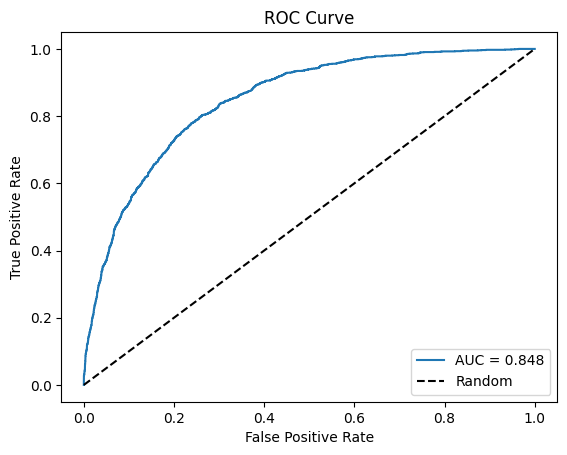

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Métrica AUC-ROC
auc = roc_auc_score(y_train, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_train, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

Por la pinta que tiene la curva, claramente el modelo que hemos creado clasifica mejor que un modelo aleatorio. El area bajo la curva de este modelo, 0.848, es bastante mejor que el 0.5 del modelo aleatorio y de hecho es una puntuación magnífica. Es un modelo muy bueno o sobresaliente.

Vamos a mostrar en un gráfico de densidad las probabilidades predichas por el modelo en el conjunto de entrenamiento.

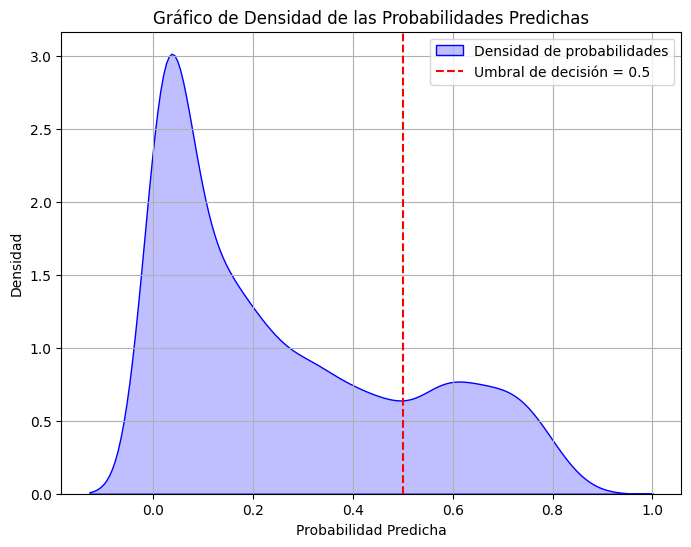

In [10]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.5, color='red', linestyle='--', label="Umbral de decisión = 0.5")
plt.legend()
plt.grid(True)
plt.show()

A la vista del gráfico de densidad, observamos que la gran masa de probabilidades se concentra fuertemente en la zona baja (en torno al 0.05), lo que demuestra que el modelo identifica con mucha contundencia a los clientes que tienen una fidelidad clara. Sin embargo, al mantener el umbral de decisión en el 0.5 por defecto, la línea de corte resulta demasiado estricta y provoca que pasemos por alto a la mayoría de los clientes que muestran indicios moderados de querer marcharse.

Desde la perspectiva estratégica de la empresa de telecomunicaciones, el coste de perder a un cliente para siempre (Falso Negativo) es muchísimo más alto que el coste de ofrecerle una promoción de retención a un cliente que en realidad pensaba quedarse (Falso Positivo). En definitiva, preferimos que no se nos escape nadie. Aunque bajar el umbral empeorará la precisión de la clase 0 (cometeremos más errores con los que se quedan, confundiéndolos con bajas), lograremos el verdadero objetivo comercial: maximizar la captura de los clientes de la clase 1 (Churn).

Por lo tanto, el siguiente paso es modificar el umbral de decisión situándolo en 0.2 para volver al modelo más sensible frente al riesgo de fuga. Vamos a recalcular la matriz de confusión y el reporte de clasificación bajo este nuevo parámetro para evaluar la mejora en la sensibilidad (Recall).

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

# Hacer predicciones (probabilidad de clase 1)
y_proba = result.predict(X_train_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.2
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_train, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[2727 1412]
 [ 213 1282]]
Matriz de confusión en porcentajes:
[[48.4  25.06]
 [ 3.78 22.75]]


Si vemos los porcentajes, vemos que el volumen de falsos negativos se ha reducido drásticamente a un 3.78% (frente al 12.12% que teníamos con el umbral estándar), lo que confirma que hemos logrado blindar casi por completo la fuga inadvertida de clientes. Por otro lado, y tal como habíamos anticipado, los falsos positivos se han elevado hasta un 25.06%; esto representa un volumen considerable de falsas alarmas, pero resulta completamente aceptable al priorizar la retención.

In [12]:
print("\nReporte de clasificación:")
print(classification_report(y_train, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.66      0.77      4139
           1       0.48      0.86      0.61      1495

    accuracy                           0.71      5634
   macro avg       0.70      0.76      0.69      5634
weighted avg       0.81      0.71      0.73      5634



A la vista del reporte de clasificación, si lo comparamos con el modelo anterior (umbral 0.5), podemos concluir que este modelo es notablemente mejor para nuestro objetivo de negocio, a pesar de que la exactitud global (accuracy) haya disminuido del 80% al 71%.

El éxito rotundo del cambio se observa en la clase 1 (Churn): la sensibilidad o recall ha subido de un insuficiente 54% a un excelente 86%. Esto significa que ahora el modelo es capaz de capturar a la gran mayoría de los clientes en riesgo de fuga, reduciendo drásticamente los casos que se nos escapan de forma inadvertida.


AUC-ROC: 0.848


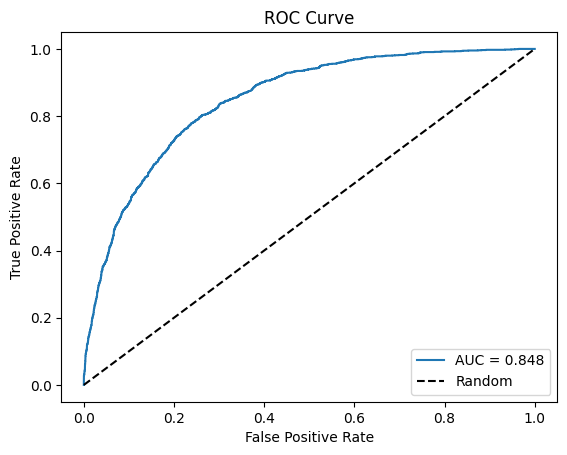

In [13]:
# Métrica AUC-ROC
auc = roc_auc_score(y_train, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_train, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

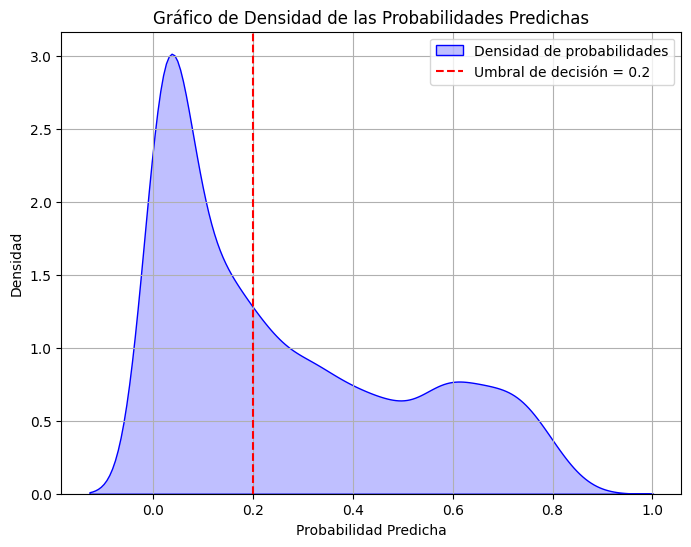

In [14]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.2, color='red', linestyle='--', label="Umbral de decisión = 0.2")
plt.legend()
plt.grid(True)
plt.show()

Ahora vamos a comparar los resultados de las métricas del primer modelo en el conjunto de entrenamiento con las del conjunto de validación para ver que tal generaliza con datos que nunca ha visto.

In [15]:
# Añadir una constante para el término independiente
X_test_const = sm.add_constant(X_test)

# Hacer predicciones (probabilidad de clase 1)
y_proba = result.predict(X_test_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[919 116]
 [167 207]]
Matriz de confusión en porcentajes:
[[65.22  8.23]
 [11.85 14.69]]


In [16]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409




AUC-ROC: 0.839


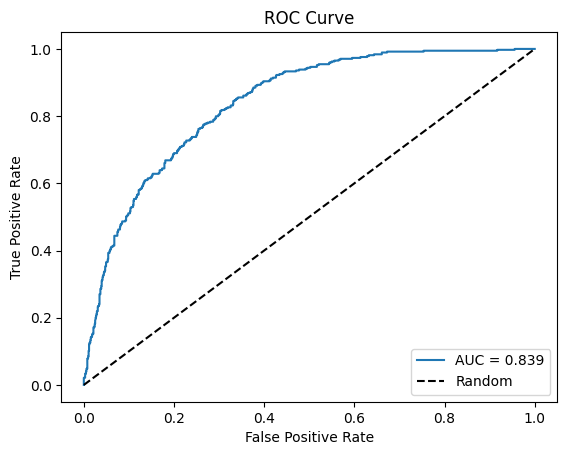

In [17]:
# Métrica AUC-ROC
auc = roc_auc_score(y_test, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

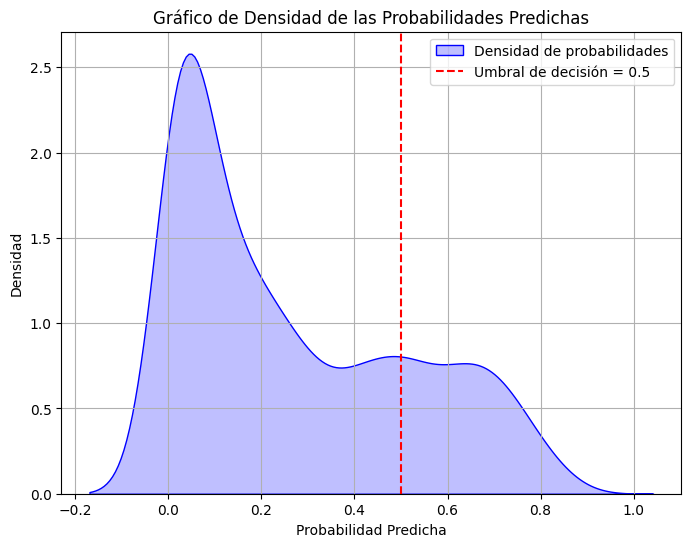

In [18]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.5, color='red', linestyle='--', label="Umbral de decisión = 0.5")
plt.legend()
plt.grid(True)
plt.show()

Si analizamos la matriz de confusión y el reporte de clasificación en Test, observamos que la exactitud global se mantiene congelada en un 80%, exactamente igual que en el entrenamiento. El indicador global de discriminación AUC-ROC apenas sufre una caída insignificante, pasando de 0.848 a 0.839. En el ámbito del Machine Learning, una pérdida de rendimiento menor al 1% al pasar de Train a Test es el escenario ideal, confirmando de manera rotunda que nuestro modelo no sufre ningún problema de sobreajuste (overfitting) y que los coeficientes calculados son estables y fiables para el negocio.

A nivel de errores, la distribución porcentual se replica casi a la perfección: los falsos negativos se sitúan en un 11.85% (frente al 12.12% en Train) y los falsos positivos en un 8.23% (frente al 7.44% en Train). El gráfico de densidad adjunto corrobora esta estabilidad visualmente, manteniendo la misma silueta bimodal con la gran concentración de clientes estables a la izquierda del umbral 0.5.

Ahora cambiamos el valor del umbral situandolo en 0.2:

In [19]:
# Añadir una constante para el término independiente
X_test_const = sm.add_constant(X_test)

# Hacer predicciones (probabilidad de clase 1)
y_proba = result.predict(X_test_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.2
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[680 355]
 [ 54 320]]
Matriz de confusión en porcentajes:
[[48.26 25.2 ]
 [ 3.83 22.71]]


In [20]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.66      0.77      1035
           1       0.47      0.86      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.71      0.73      1409



Al analizar las métricas, confirmamos que el modelo replica con una exactitud asombrosa el rendimiento del entrenamiento, lo que demuestra su total robustez y nulo sobreajuste. La exactitud global (accuracy) se consolida en el 71% y el F1-score de la clase positiva se clava en el 61%.

El dato clave para la viabilidad del proyecto es que la sensibilidad o recall de la clase 1 se mantiene intacto en un excelente 86%. En términos reales, el modelo detectará con éxito a 320 de los 374 clientes que van a abandonar la compañía en este conjunto de datos nuevos, permitiendo que el departamento de marketing actúe a tiempo. Los clientes que sufren una fuga inadvertida (falsos negativos) suponen un residual 3.83%. El peaje de falsas alarmas (falsos positivos) se estabiliza en el 25.20%, una cifra completamente asumible dentro del presupuesto comercial asignado para la campaña de fidelización.

En conclusión, la modificación del umbral de decisión a 0.2 se valida como la solución óptima para el problema de negocio planteado, transformando un algoritmo inicialmente sesgado en una herramienta proactiva de retención altamente eficiente y perfectamente preparada para producción.

In [21]:
# Calcular el área hacia la derecha del umbral de 0.5
area_right = np.sum(y_proba > 0.5) / len(y_proba)
print(f"El área hacia la derecha del umbral 0.5 es: {area_right:.4f}")

# Calcular el área hacia la derecha del umbral de 0.2
area_right = np.sum(y_proba > 0.2) / len(y_proba)
print(f"El área hacia la derecha del umbral 0.2 es: {area_right:.4f}")

El área hacia la derecha del umbral 0.5 es: 0.2292
El área hacia la derecha del umbral 0.2 es: 0.4791


A la vista de los resultados numéricos, confirmamos el impacto directo que tiene la elección del umbral sobre la dimensión:

- Con el umbral estándar de 0.5, el área hacia la derecha es de 0.2292. Esto significa que el modelo solo calificaría en riesgo de fuga al 22.92% del total de los clientes. En el caso de hacer campaña sería muy reducida y económica para la empresa, pero comercialmente ineficaz, ya que dejaría sin detectar a casi la mitad de las bajas reales (alto volumen de falsos negativos).

- Con nuestro umbral optimizado de 0.2, el área hacia la derecha se duplica hasta 0.4791. Esto implica que pasamos a etiquetar en situación de riesgo al 47.91% de la cartera de clientes (casi la mitad de la muestra analizada).

En conclusión bajar el umbral a 0.2 duplica el volumen de alertas, exigirá acciones de fidelización para el 48% de los usuarios.

Ahora vamos a intentar mejorar nuestro modelo de Regresión Logística y, para ello, realizaremos una selección distinta de las variables predictoras (Feature Selection). Está claro que no podemos incluir todas las columnas de golpe en el modelo, ya que se generaría dependencia lineal perfecta (multicolinealidad) debido al exceso de variables binarizadas, un problema estadístico que desestabiliza los coeficientes e impide la convergencia del algoritmo.

In [22]:
# Reconstruir las variables categóricas originales
def reverse_one_hot_encoding(df, column_prefixes):
    recovered_columns = {}
    for prefix in column_prefixes:
        # Filtrar columnas que corresponden al prefijo
        cols = [col for col in df.columns if col.startswith(prefix + '_')]
        
        # Extraer nombres de categorías de las columnas
        categories = [col.split('_', 1)[1] for col in cols]
        
        # Crear una nueva columna categórica
        recovered_columns[prefix] = np.select(
            condlist=[df[col] == 1 for col in cols],
            choicelist=categories,
            default='missing'  # Categoría eliminada
        )
    
    return pd.DataFrame(recovered_columns)

# Definir los prefijos de las variables originales
column_prefixes = [
    'Partner', 'Dependents', 'MultipleLines', 'InternetService', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Aplicar la función para reconstruir las variables categóricas originales
recovered_data = reverse_one_hot_encoding(data, column_prefixes)
recovered_data['Churn'] = data['Churn'].astype(str)

# Resultado
print("\nDataset recuperado:")
recovered_data.head()


Dataset recuperado:


,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Yes,missing,missing,missing,missing,Yes,missing,missing,missing,missing,missing,Yes,Electronic check,0
1,missing,missing,missing,missing,Yes,missing,Yes,missing,missing,missing,One year,missing,Mailed check,0
2,missing,missing,missing,missing,Yes,Yes,missing,missing,missing,missing,missing,Yes,Mailed check,1
3,missing,missing,missing,missing,Yes,missing,Yes,Yes,missing,missing,One year,missing,missing,0
4,missing,missing,missing,Fiber optic,missing,missing,missing,missing,missing,missing,missing,Yes,Electronic check,1


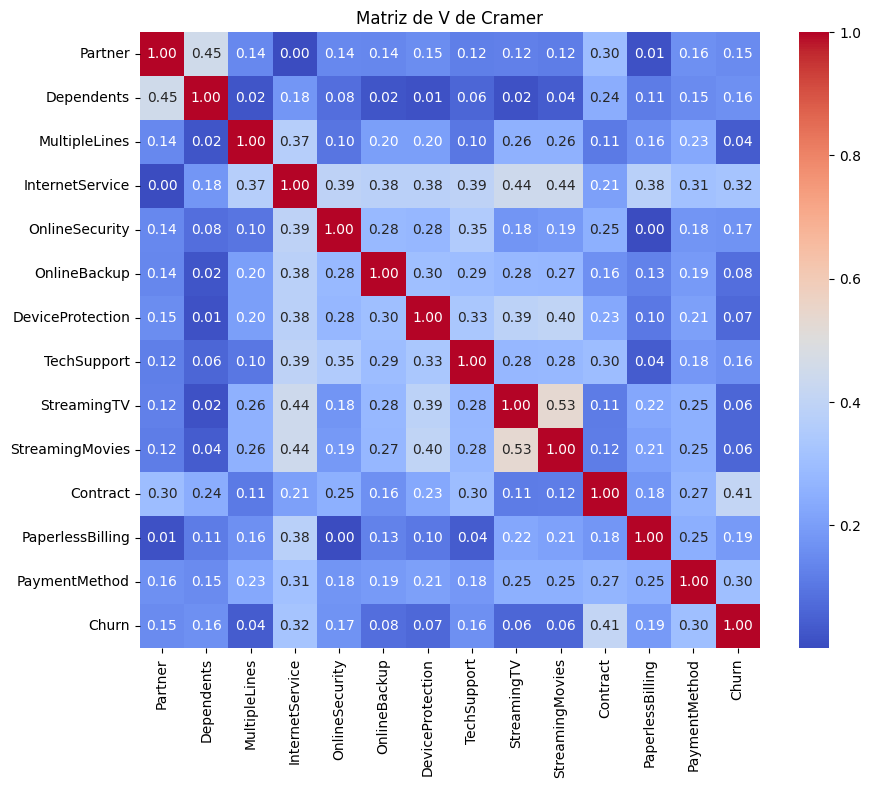

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from itertools import combinations

# Función para calcular V de Cramér
def cramers_v(confusion_matrix):
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()  # Número total de observaciones
    k = min(confusion_matrix.shape)  # Número de categorías en la variable
    return np.sqrt(chi2 / (n * (k - 1)))

# Identificar las variables categóricas
category_columns = recovered_data.select_dtypes(include=['object', 'category', 'str']).columns

# Crear una matriz vacía para almacenar los valores de V de Cramer
matrix = pd.DataFrame(index=category_columns, columns=category_columns)

# Calcular V de Cramer para cada par de variables categóricas
for var1, var2 in combinations(category_columns, 2):
    contingency_table = pd.crosstab(recovered_data[var1], recovered_data[var2])
    value = cramers_v(contingency_table)
    matrix.loc[var1, var2] = value
    matrix.loc[var2, var1] = value

# Llenar la diagonal con 1s
#np.fill_diagonal(matrix.values, 1)

# Llenar la diagonal con 1s (Solución al error: usando Pandas nativo)
for col in category_columns:
    matrix.loc[col, col] = 1.0

# Convertir a tipo float
matrix = matrix.astype(float)

# Visualizar la matriz como heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de V de Cramer")
plt.show()

**Variables críticas para el modelo**: Se identifican tres variables principales que presentan la mayor fuerza de asociación con la baja de clientes: Contract (0.41), InternetService (0.32) y PaymentMethod (0.30).
**Variables redundantes**: Se detecta una correlación elevada entre StreamingTV y StreamingMovies (0.53).
**Variables irrelevantes**: Los servicios adicionales de soporte y entretenimiento como StreamingTV, StreamingMovies, DeviceProtection y OnlineBackup muestran coeficientes de asociación inferiores a 0.10 con el Churn.

Vamos a analizar a ver como son las relaciones entre la objetivo y las variables numéricas.

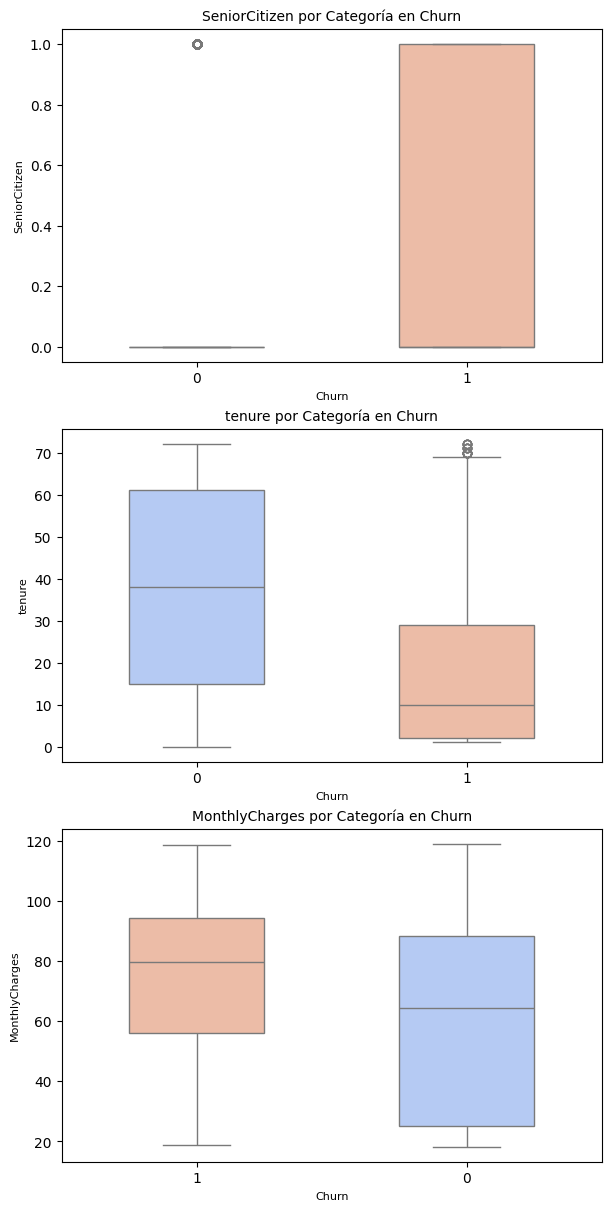

In [24]:
target_var = 'Churn'

# Identificar las columnas numéricas
numeric_columns = ['SeniorCitizen','tenure','MonthlyCharges']

# Crear el grid de subplots
n_vars = len(numeric_columns)
fig, axes = plt.subplots(n_vars, 1, figsize=(6, 4 * n_vars), constrained_layout=True)

# Generar un boxplot por cada variable numerica
for ax, var in zip(axes, numeric_columns):
    # Ordenar las categorías según la mediana calculada
    medians = data.groupby(target_var)[var].median().sort_values(ascending=False)
    ordered_categories = medians.index
    
    # Generar el boxplot con las categorías ordenadas
    sns.boxplot(x=target_var, y=var, data=data, order=ordered_categories, palette='coolwarm', hue=target_var, legend=False, ax=ax, width=0.5)
    ax.set_title(f'{var} por Categoría en {target_var}', fontsize=10)
    ax.set_xlabel(target_var, fontsize=8)
    ax.set_ylabel(var, fontsize=8)

# Mostrar el grid de boxplots
plt.show()

Los clientes de la tercera edad tienen una tasa de abandono proporcionalmente más alta.
El precio es un detonante directo de la fuga. Las tarifas más caras están empujando a los clientes a abandonar la compañía.
El precio es un detonante directo de la fuga. Las tarifas más caras están empujando a los clientes a abandonar la compañía.

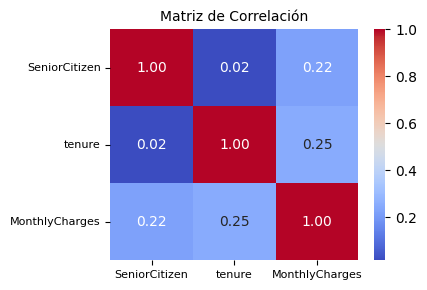

In [25]:
# Correlación entre variables numéricas
correlation_matrix = data[['SeniorCitizen','tenure','MonthlyCharges']].corr()

plt.figure(figsize=(4, 3))

# Dibujar la matriz de correlación como un heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, annot_kws={"size": 10})
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title("Matriz de Correlación", fontsize=10)
plt.show()

Al estar todos los valores muy por debajo de 0.30, confirmamos que no existe multicolinealidad entre las variables numéricas. Se pueden meter juntas en la Regresión Logística de forma segura.

In [26]:
# 1. Lista de prefijos de variables categóricas que decidimos eliminar (ruido < 0.10 o redundantes)
prefixes_to_remove = [
    'StreamingTV', 
    'StreamingMovies', 
    'DeviceProtection', 
    'OnlineBackup', 
    'MultipleLines'
]

# 2. Filtrar automáticamente todas las columnas dummy que empiecen por esos prefijos
columns_to_remove = [col for col in data.columns if any(col.startswith(prefix) for prefix in prefixes_to_remove)]

# Agregar una columna específica que también deseas eliminar
columns_to_remove.append('Churn')

# 4. Separar las variables predictoras (X) y la variable objetivo (y)
X = data.drop(columns=columns_to_remove)
y = data['Churn']


In [27]:
# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
# Añadir una constante para el término independiente
X_train_const = sm.add_constant(X_train)

# Crear y ajustar el modelo
logit_model = sm.Logit(y_train, X_train_const).fit(maxiter=100)

# Resumen completo
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.418012
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5618
Method:                           MLE   Df Model:                           15
Date:                Thu, 11 Jun 2026   Pseudo R-squ.:                  0.2775
Time:                        18:12:26   Log-Likelihood:                -2355.1
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -1.1067      

El modelo presenta una bondad de ajuste sólida con un Pseudo R-squared de 0.2775, un valor óptimo para la predicción de bajas en el sector de las telecomunicaciones. Al evaluar la significación individual de los predictores (mediante el p-valor), confirmamos que variables como Partner_Yes (p = 0.672) o PaymentMethod_Credit card (p = 0.765) carecen de impacto estadístico y actúan como ruido residual.

In [29]:
# Obtener los coeficientes
coefficients = logit_model.params

# Calcular los odds ratios aplicando exp a los coeficientes
odds_ratios = np.exp(coefficients)

# Crear un DataFrame con las dos columnas: coeficientes y odds ratios
tab_coefs_odds = pd.DataFrame({
    'Coeficientes': coefficients,
    'Odds Ratios': odds_ratios
})

# Mostrar la tabla
tab_coefs_odds.sort_values(by='Coeficientes',ascending=False)

,Coeficientes,Odds Ratios
InternetService_Fiber optic,0.514040,1.672033
PaymentMethod_Electronic check,0.431915,1.540204
PaperlessBilling_Yes,0.408152,1.504036
SeniorCitizen,0.182026,1.199645
PaymentMethod_Mailed check,0.089319,1.093429
Partner_Yes,0.036396,1.037067
MonthlyCharges,0.011511,1.011578
tenure,-0.029922,0.970521
PaymentMethod_Credit card (automatic),-0.038075,0.962641
Dependents_Yes,-0.246218,0.781752


Pasamos a predecir en el conjunto de validación para ver como generaliza.

In [30]:
# Añadir una constante para el término independiente
X_test_const = sm.add_constant(X_test)

# Hacer predicciones (probabilidad de clase 1)
y_proba = logit_model.predict(X_test_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[925 110]
 [175 199]]
Matriz de confusión en porcentajes:
[[65.65  7.81]
 [12.42 14.12]]


In [31]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Tras evaluar y contrastar el rendimiento del segundo modelo optimizado frente al modelo inicial en el conjunto de validación (Test) utilizando el umbral estándar de 0.5, se consolida de forma empírica el éxito de nuestra estrategia de selección de características (Feature Selection).

El nuevo modelo simplificado alcanza una **exactitud global idéntica del 80%** y mantiene la **precisión de la clase positiva inmóvil en el 64%**. El principal hallazgo radica en el comportamiento de las matrices de confusión: al eliminar los servicios adicionales que generaban ruido matemático, el algoritmo se ha vuelto estadísticamente más selectivo. Esto ha permitido **reducir la tasa de falsas alarmas (Falsos Positivos) del 8.23% (116 casos) al 7.81% (110 casos)**. Como contrapartida marginal debido a su mayor rigidez, **la sensibilidad (recall) sufre una oscilación menor de apenas el 2% (pasando del 55% al 53%)**.


AUC-ROC: 0.836


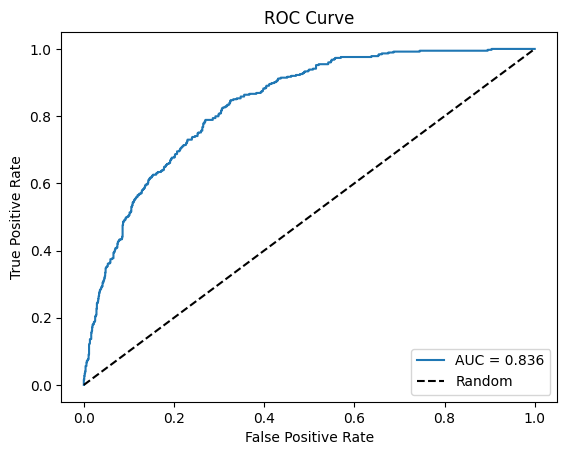

In [32]:
# Métrica AUC-ROC
auc = roc_auc_score(y_test, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

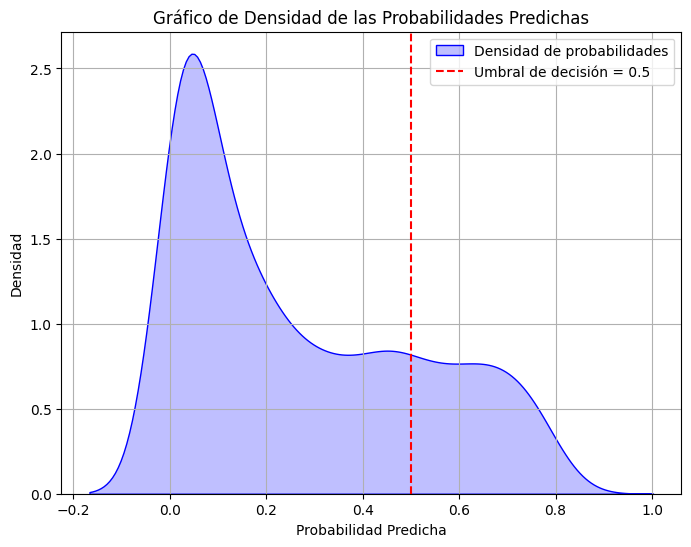

In [33]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.5, color='red', linestyle='--', label="Umbral de decisión = 0.5")
plt.legend()
plt.grid(True)
plt.show()

El análisis de la **Curva ROC** y del **Gráfico de Densidad de Probabilidades** para el modelo optimizado confirma de manera concluyente la validez de la selección de características efectuada.

El indicador global de discriminación **AUC-ROC se sitúa en un excelente 0.836**, experimentando una variación marginal e insignificante de apenas un -0.003 en comparación con el modelo original (0.839). Este resultado certifica que las variables eliminadas por ruido o redundancia mediante la V de Cramér no aportaban valor real al poder de separación del algoritmo. El modelo simplificado retiene prácticamente el 100% de la capacidad predictiva original.

Vamos a modificar el umbral de decisión estándar (0.5) y situarlo en uno más bajo porque, en este contexto de negocio, es preferible prevenir que lamentar. **Preferimos asumir falsos positivos** (alertas de clientes que no se iban a ir, lo que supone un pequeño gasto en ofertas innecesarias) **antes que tolerar falsos negativos** (clientes que se dan de baja sin que el modelo los detecte, perdiendo el cliente por completo).

Dado que el entorno de Kaggle no define un umbral operativo, se ha realizado un análisis de simulación para los umbrales 0.2, 0.3 y 0.4 con el fin de evaluar el impacto financiero y comercial de la campaña de retención:

In [34]:
## Umbral 0.2

# Añadir una constante para el término independiente
X_test_const = sm.add_constant(X_test)

# Hacer predicciones (probabilidad de clase 1)
y_proba = logit_model.predict(X_test_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.2
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[679 356]
 [ 55 319]]
Matriz de confusión en porcentajes:
[[48.19 25.27]
 [ 3.9  22.64]]


In [35]:
## Umbral 0.3

# Convertir las probabilidades en predicciones binarias
threshold = 0.3
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[769 266]
 [ 93 281]]
Matriz de confusión en porcentajes:
[[54.58 18.88]
 [ 6.6  19.94]]


In [36]:
## Umbral 0.4

threshold = 0.4
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[847 188]
 [131 243]]
Matriz de confusión en porcentajes:
[[60.11 13.34]
 [ 9.3  17.25]]


In [42]:
# Calcular el área hacia la derecha del umbral de 0.2
area_right = np.sum(y_proba > 0.2) / len(y_proba)
print(f"El área hacia la derecha del umbral 0.2 es: {area_right:.4f}")

# Calcular el área hacia la derecha del umbral de 0.3
area_right = np.sum(y_proba > 0.3) / len(y_proba)
print(f"El área hacia la derecha del umbral 0.3 es: {area_right:.4f}")

# Calcular el área hacia la derecha del umbral de 0.4
area_right = np.sum(y_proba > 0.4) / len(y_proba)
print(f"El área hacia la derecha del umbral 0.4 es: {area_right:.4f}")

El área hacia la derecha del umbral 0.2 es: 0.4791
El área hacia la derecha del umbral 0.3 es: 0.3882
El área hacia la derecha del umbral 0.4 es: 0.3059


Si la compañía dispone de un **presupuesto holgado** o el **coste de la acción de retención es muy bajo** (ej. campañas automatizadas por email), el umbral de **0.2** es el óptimo, ya que minimiza las fugas a solo 55 clientes inadvertidos (Recall del 85.29%).

Si la compañía busca **optimizar el retorno de inversión (ROI)** mitigando el coste de las falsas alarmas, el **umbral de 0.3 se consolida como el punto de **equilibrio óptimo**. Este umbral eleva la precisión por encima del 51.37%, logrando ahorrar 90 llamadas promocionales innecesarias con respecto al umbral de 0.2, mientras sigue blindando la cartera al capturar con éxito al 75.13% de los clientes en riesgo inminente de abandono.

Por lo tanto, se descarta el umbral por defecto de 0.5 por su ineficacia comercial y se propone el despliegue del modelo bajo un umbral operativo de 0.3 como la solución más eficiente y equilibrada para el negocio.

In [37]:
# Añadir una constante para el término independiente
X_test_const = sm.add_constant(X_test)

# Hacer predicciones (probabilidad de clase 1)
y_proba = logit_model.predict(X_test_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.3
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[769 266]
 [ 93 281]]
Matriz de confusión en porcentajes:
[[54.58 18.88]
 [ 6.6  19.94]]


In [38]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1035
           1       0.51      0.75      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [43]:
# Calcular el área hacia la derecha del umbral de 0.3
area_right = np.sum(y_proba > 0.3) / len(y_proba)
print(f"El área hacia la derecha del umbral 0.3 es: {area_right:.4f}")

El área hacia la derecha del umbral 0.3 es: 0.3882



AUC-ROC: 0.836


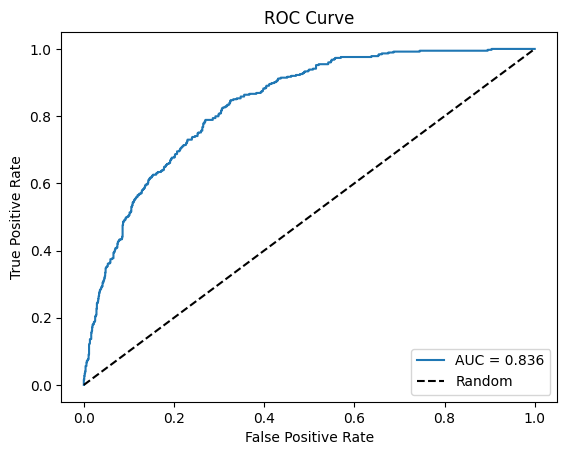

In [39]:
# Métrica AUC-ROC
auc = roc_auc_score(y_test, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

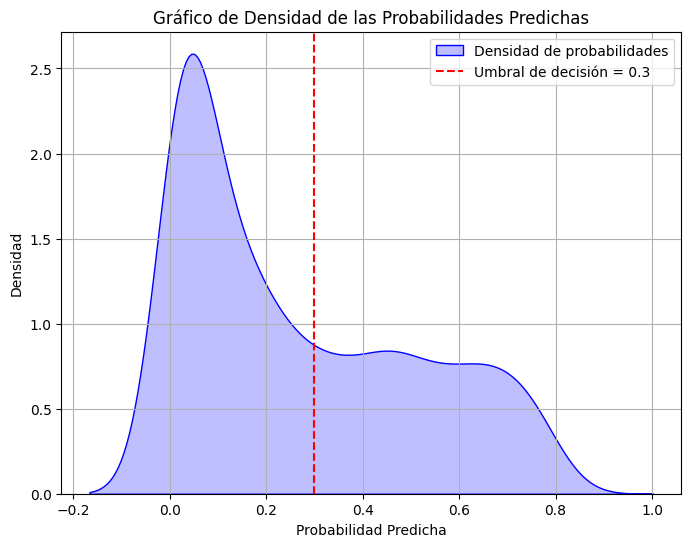

In [40]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.3, color='red', linestyle='--', label="Umbral de decisión = 0.3")
plt.legend()
plt.grid(True)
plt.show()

Este proyecto demuestra cómo el análisis estadístico riguroso se traduce de forma directa en valor estratégico para el negocio. A lo largo del estudio, logramos aplicar con éxito el principio de parsimonia mediante el análisis de la V de Cramér y los diagramas de caja, reduciendo la complejidad del dataset original al eliminar variables redundantes sin perder poder predictivo.

Finalmente, la evaluación integrada de la Curva ROC (AUC = 0.836), el gráfico de densidad bimodal y el análisis de sensibilidad nos permitieron romper con el umbral genérico de 0.5 para diseñar una solución a medida de las necesidades financieras de la empresa: un umbral operativo de 0.3. Con este modelo optimizado, la compañía de telecomunicaciones no solo cuenta con un algoritmo ligero, robusto y fácil de mantener en producción, sino con una potente herramienta comercial capaz de blindar la cartera de clientes, anticipando y reteniendo de forma proactiva al 75.13% de las fugas con el máximo retorno de inversión posible.